# PCA from Scratch — Hands-on Tutorial

In this notebook we'll build PCA step by step using only numpy:
1. **Build PCA** — centre, covariance matrix, eigendecomposition
2. **Projection and reconstruction** — project onto PCs, then reconstruct back to the original space
3. **PC2-only reconstruction** — see what happens when you keep the wrong component

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## Part 1: Build PCA Step by Step

We generate 2D data where $y \approx 2x$ plus some noise.
Your job is to find the principal components by hand.

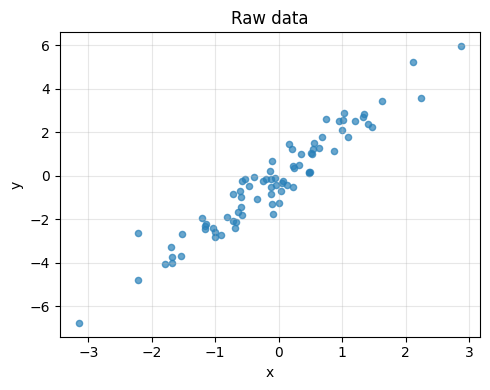

In [2]:
# Generate correlated 2D data
np.random.seed(12)
n = 80
x0 = np.random.normal(0, 1, n)
y0 = 2 * x0 + np.random.normal(0, 0.6, n)

# Stack into an (n, 2) array — each row is a data point
data = np.column_stack([x0, y0])

plt.figure(figsize=(5, 4))
plt.scatter(data[:, 0], data[:, 1], color='#2980b9', s=20, alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Raw data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 1: Centre the data

PCA looks for directions of maximum **variance**. Variance is measured relative
to the mean, so the first step is to subtract the mean of each variable.

In [ ]:
data_mean = data.mean(axis=0)
centred = data - data_mean

### Step 2: Compute the covariance matrix

The covariance matrix is a 2×2 matrix that captures how the two variables
co-vary. The diagonal entries are the variances, the off-diagonals are the
covariances.

In [ ]:
cov_matrix = np.cov(centred, rowvar=False)
print(cov_matrix)

### Step 3: Eigendecomposition

The eigenvectors of the covariance matrix point in the directions of maximum
variance. The eigenvalues tell you how much variance each direction captures.

The entries of each eigenvector — its weights on the original features — are
called the **loadings**. Reading them tells you *what* a PC is built from
(here, how much $x$ vs $y$ each PC mixes together).

In [ ]:
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# eigh returns ascending order -- flip to descending (PC1 first)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

In [ ]:
# Print what you found
for i in range(2):
    print(f"PC{i+1}: eigenvalue = {eigvals[i]:.3f}, "
          f"direction = [{eigvecs[0, i]:.3f}, {eigvecs[1, i]:.3f}]")

# Fraction of total variance captured by each PC
total_var = eigvals.sum()
for i in range(2):
    print(f"PC{i+1} captures {eigvals[i] / total_var * 100:.1f}% of variance")

### Visualise: PC axes on the original data

The arrows show the eigenvectors scaled by their eigenvalues — longer arrow
means more variance in that direction.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(data[:, 0], data[:, 1], color='#2980b9', s=20, alpha=0.7)

colors_pc = ['#e74c3c', '#27ae60']
for i in range(2):
    vec = eigvecs[:, i]
    scale = 3 * np.sqrt(eigvals[i])
    # Draw arrow in both directions
    ax.annotate('', xy=data_mean + scale * vec, xytext=data_mean,
                arrowprops=dict(arrowstyle='->', color=colors_pc[i], lw=3))
    ax.annotate('', xy=data_mean - scale * vec, xytext=data_mean,
                arrowprops=dict(arrowstyle='->', color=colors_pc[i], lw=3))
    ax.plot([], [], color=colors_pc[i], lw=3,
            label=f'PC{i+1} (var={eigvals[i]:.2f})')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Data with principal component axes')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 2: Projection and Reconstruction

Now we'll use the eigenvectors to rotate the data into PC space,
then reconstruct it using only PC1.

### Rotation into PC space

Multiplying the centred data by the full eigenvector matrix rotates it
into a new coordinate system where the axes are PC1 and PC2. No information
is lost — this is just a change of basis.

Each point's coordinates in this new system are its **scores** — how far the
point lies along each PC. A score is just the centred point projected onto an
eigenvector, $z = \vec v \cdot \vec x_c$.

In [ ]:
# Rotate into PC space: (n, 2) @ (2, 2) = (n, 2)
# Each row of projected gives a point's [PC1, PC2] coordinates
projected = centred @ eigvecs

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(data[:, 0], data[:, 1], color='#2980b9', s=20, alpha=0.7)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Original space')

axes[1].scatter(projected[:, 0], projected[:, 1], color='#2980b9', s=20, alpha=0.7)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PC space')

plt.tight_layout()
plt.show()

### Reconstruction from PC1 only

Now the key step: we throw away PC2 and reconstruct the data using only PC1.

Here's what's happening mathematically:

1. `centred @ eigvecs[:, 0:1]` — Project onto PC1 only.
   `eigvecs[:, 0:1]` is a (2, 1) column vector (PC1's direction).
   Result is (n, 1): each point's **score** — its scalar coordinate along PC1.

2. `... @ eigvecs[:, 0:1].T` — Map back to 2D.
   Multiply the (n, 1) scores by the (1, 2) PC1 direction transposed.
   Result is (n, 2): 2D points, but all constrained to lie along the PC1 line.
   This is still centred (mean-subtracted).

3. `+ data_mean` — Add the mean back to return to the original coordinate frame.

The net effect: each original point gets "snapped" onto the PC1 line.
The distance from the original to the snapped point is the information
we lost by dropping PC2.

In [ ]:
reconstructed_pc1 = centred @ eigvecs[:, 0:1] @ eigvecs[:, 0:1].T + data_mean

In [ ]:
# Visualise: original data (faded) vs PC1 reconstruction
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(data[:, 0], data[:, 1], color='#2980b9', s=20, alpha=0.2,
           label='Original')
ax.scatter(reconstructed_pc1[:, 0], reconstructed_pc1[:, 1], color='#e74c3c',
           s=20, alpha=0.8, label='PC1 reconstruction')

# Draw faint lines connecting each point to its reconstruction
for orig, recon in zip(data, reconstructed_pc1):
    ax.plot([orig[0], recon[0]], [orig[1], recon[1]],
            color='grey', linewidth=0.5, alpha=0.5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('PC1 reconstruction in original space')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reconstruction error
recon_error_pc1 = np.mean(np.sum((data - reconstructed_pc1) ** 2, axis=1))
print(f"Mean reconstruction error (PC1 only): {recon_error_pc1:.4f}")

### Think about it

- The reconstructed points all sit on a line. Why?
- The grey connector lines show what was lost. Are they large or small compared
  to the overall spread of the data?
- What does the reconstruction error represent physically?

---
## Part 3: PC2-Only Reconstruction

What if we kept the *wrong* component? Let's reconstruct using only PC2
and compare.

In [ ]:
reconstructed_pc2 = centred @ eigvecs[:, 1:2] @ eigvecs[:, 1:2].T + data_mean

In [ ]:
# Compare PC1 vs PC2 reconstruction side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# PC1
axes[0].scatter(data[:, 0], data[:, 1], color='#2980b9', s=15, alpha=0.15)
axes[0].scatter(reconstructed_pc1[:, 0], reconstructed_pc1[:, 1],
                color='#e74c3c', s=20, alpha=0.8)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Keep PC1 only')

# PC2
axes[1].scatter(data[:, 0], data[:, 1], color='#2980b9', s=15, alpha=0.15)
axes[1].scatter(reconstructed_pc2[:, 0], reconstructed_pc2[:, 1],
                color='#27ae60', s=20, alpha=0.8)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Keep PC2 only')

plt.tight_layout()
plt.show()

# Compare errors
recon_error_pc2 = np.mean(np.sum((data - reconstructed_pc2) ** 2, axis=1))
print(f"Reconstruction error — PC1 only: {recon_error_pc1:.4f}")
print(f"Reconstruction error — PC2 only: {recon_error_pc2:.4f}")

### Think about it

- How do the reconstruction errors compare? By how much?
- Look at the PC2-only plot. The green points cluster near the mean —
  they've lost the $y \approx 2x$ trend entirely. Why?
- In this dataset, PC1 captured the **signal** (the linear relationship)
  and PC2 captured the **noise**. PCA figured this out automatically,
  without being told the model.

---
## Part 4: What's Inside a PC? Reading Loadings

In 2D, a loading just says how much $x$ vs $y$ a PC mixes. The idea gets far more
useful in high dimensions, where each PC is a blend of *many* features and the
**loadings** — the entries of the eigenvector — tell you *what* the PC responds to.

Here are **400 spectra**, each measured in **120 wavelength bins**. Buried in a
bright, smoothly varying continuum is a *faint* narrow emission line at bin 70,
whose strength changes from spectrum to spectrum. Can PCA find it?

In [ ]:
# 400 spectra x 120 wavelength bins
rng = np.random.default_rng(1)
n_spec, n_bins = 400, 120
w = np.arange(n_bins)
line_profile = np.exp(-0.5 * ((w - 70) / 2.5) ** 2)   # narrow Gaussian line at bin 70

# Each spectrum: bright continuum (varies a lot) + a FAINT line (varies a little) + noise
line_strength = rng.normal(0.6, 0.25, n_spec)         # per-spectrum line amplitude (the "truth")
spectra = []
for i in range(n_spec):
    continuum = rng.normal(5, 1.5) + rng.normal(0, 0.02) * w   # bright, smooth, big variance
    spectra.append(continuum + line_strength[i] * line_profile
                   + rng.normal(0, 0.15, n_bins))              # + measurement noise
spectra = np.array(spectra)                            # shape (400, 120)

plt.figure(figsize=(8, 3))
for i in range(8):
    plt.plot(w, spectra[i], lw=0.8, alpha=0.7)
plt.axvline(70, color='grey', ls='--', lw=1, label='line at bin 70')
plt.xlabel('wavelength bin'); plt.ylabel('flux'); plt.legend(fontsize=8)
plt.title('8 of the 400 spectra - the faint line is hard to spot by eye')
plt.tight_layout(); plt.show()

### Run PCA and pull out the loadings

Same recipe as Part 1 - centre, covariance, eigendecompose, sort - just in 120
dimensions now. The columns of `eigvecs_s` are the loadings: `eigvecs_s[:, k]` is
PC(k+1)'s weight across all 120 wavelength bins.

In [ ]:
centred_s = spectra - spectra.mean(axis=0)
cov_s = np.cov(centred_s, rowvar=False)              # 120 x 120
eigvals_s, eigvecs_s = np.linalg.eigh(cov_s)

order = np.argsort(eigvals_s)[::-1]
eigvals_s = eigvals_s[order]
eigvecs_s = eigvecs_s[:, order]
var_frac_s = eigvals_s / eigvals_s.sum()

In [ ]:
# Loadings of the first six PCs over wavelength.
# STRUCTURE in a loading = the PC responds to specific wavelengths (real signal).
# A flat / random loading = the PC is just noise.
fig, axes = plt.subplots(2, 3, figsize=(11, 5),
                         gridspec_kw={'wspace': 0.3, 'hspace': 0.45})
for k, ax in enumerate(axes.flat):
    ax.plot(w, eigvecs_s[:, k], lw=1.2, color='#2980b9')
    ax.axhline(0, color='grey', lw=0.5)
    ax.axvline(70, color='red', ls=':', lw=1, alpha=0.6)
    ax.set_title(f'PC{k+1} loading - {var_frac_s[k]*100:.2g}% var', fontsize=10)
    ax.set_xlabel('wavelength bin')
plt.tight_layout(); plt.show()

### Explore: connect a loading to a score

One of those PCs has a sharp spike right at bin 70 (the red dotted line) - that's
the component encoding the emission line. Notice it is **not** PC1: PC1 carries the
bright continuum, which has far more variance.

Project the spectra onto the line-carrying PC to get each spectrum's **score**, and
check it against the true `line_strength` we put in.

In [ ]:
# PC3 (index 2) carries the line -- read off the spike at bin 70 in the grid above.
k_line = 2
scores_line = centred_s @ eigvecs_s[:, k_line]

plt.figure(figsize=(5, 4))
plt.scatter(scores_line, line_strength, s=15, alpha=0.6, color='#2980b9')
plt.xlabel(f'PC{k_line + 1} score')
plt.ylabel('true line strength')
plt.title(f'PC{k_line + 1} score tracks the line strength')
plt.tight_layout(); plt.show()

# Sign of an eigenvector is arbitrary, so look at the magnitude of the correlation
print("correlation:", np.corrcoef(scores_line, line_strength)[0, 1])

### Think about it

- Which PC carried the emission line - PC1, or a much lower-variance one? What
  does that say about the idea that "more variance = more important"?
- Look at PC1's loading. It's broad and smooth, with no spike at bin 70. What
  physical part of the spectrum is it describing?
- If you kept only PC1 and PC2 and threw the rest away, would the line survive?